In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import figurefirst as fifi
import fly_plot_lib.plot as fpl
import os

import matplotlib as mpl

from splitflow import WindDataProcessing

Using device: cpu


In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

oranges = plt.cm.Oranges(np.linspace(0, 1, 10))
blues = plt.cm.Blues(np.linspace(0, 1, 10))
color_blue = oranges[6]
color_orange = blues[6]

In [3]:
layout = fifi.svg_to_axes.FigureLayout('f2_DRAFT6.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



FileNotFoundError: [Errno 2] No such file or directory: 'f2_DRAFT6.svg'

# Make colorbars separately 

In [4]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    '''
    https://stackoverflow.com/a/18926541
    '''
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap




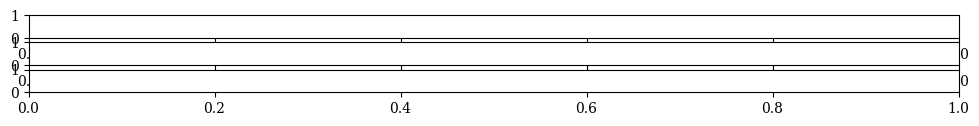

In [5]:
cmap_base = 'bwr'
vmin, vmax = 0.5, 1
Spectral_half_cmap = truncate_colormap(cmap_base, vmin, vmax)



fig, ax = plt.subplots(nrows=3, figsize=(12,1))
ax[0] = layout.axes[('ColorBars', 'cb1')] 
ax[1] = layout.axes[('ColorBars', 'cb2')] 
ax[2] = layout.axes[('ColorBars', 'cb3')] 




sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=0, vmax=1)) 
fig.colorbar(sm, cax=ax[0],  orientation='horizontal')
fifi.mpl_functions.adjust_spines(ax[0], ['bottom'], xticks=[0,1], spine_locations={'bottom':5}, tick_length=3, linewidth=.5)

sm = mpl.cm.ScalarMappable(cmap=Spectral_half_cmap, norm=mpl.colors.Normalize(vmin=0, vmax=50)) 
fig.colorbar(sm, cax=ax[1], orientation='horizontal')
fifi.mpl_functions.adjust_spines(ax[1], ['bottom'], xticks=[0,50], spine_locations={'bottom':5}, tick_length=3, linewidth=.5)

sm = mpl.cm.ScalarMappable(cmap=cmap_base, norm=mpl.colors.Normalize(vmin=-50, vmax=50)) 
fig.colorbar(sm, cax=ax[2],  orientation='horizontal')
fifi.mpl_functions.adjust_spines(ax[2], ['bottom'], xticks=[-50,0,50], spine_locations={'bottom':5}, tick_length=3, linewidth=.5)

fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)
fifi.mpl_functions.set_fontsize(ax[2], 6)

layout.append_figure_to_layer(layout.figures['ColorBars'], 'ColorBars', cleartarget=True)


#ax[0].set_aspect(.1)
#ax[1].set_aspect(2)
#ax[2].set_aspect(2)


## Load in dfs

In [6]:
df_XY_steady = WindDataProcessing.load_wind_data('../../../Data/CFD/2D_PlanarSlices/XY_steady/','csv', coord_system='CFD' )

XY_up__0.csv
XY_up__1.csv
XY_up__2.csv
XY_up__3.csv
XY_up__4.csv
XY_up__5.csv
XY_up__6.csv
XY_up__7.csv
XY_up__8.csv
XY_up__9.csv
XY_up__10.csv
XY_up__11.csv
XY_up__12.csv
XY_up__13.csv
XY_up__14.csv
XY_up__15.csv
XY_up__16.csv
XY_up__17.csv
XY_up__18.csv
XY_up__19.csv
XY_up__20.csv
XY_up__21.csv
XY_up__22.csv
XY_up__23.csv
XY_up__24.csv
XY_up__25.csv
XY_up__26.csv
XY_up__27.csv
XY_up__28.csv
XY_up__29.csv
XY_up__30.csv
XY_up__31.csv
XY_up__32.csv
XY_up__33.csv
XY_up__34.csv
XY_up__35.csv
XY_up__36.csv
XY_up__37.csv
XY_up__38.csv
XY_up__39.csv
XY_up__40.csv
XY_up__41.csv
XY_up__42.csv
XY_up__43.csv
XY_up__44.csv
XY_up__45.csv
XY_up__46.csv
XY_up__47.csv
XY_up__48.csv
XY_up__49.csv
XY_up__50.csv
XY_up__51.csv
XY_up__52.csv
XY_up__53.csv
XY_up__54.csv
XY_up__55.csv
XY_up__56.csv
XY_up__57.csv
XY_up__58.csv
XY_up__59.csv
XY_up__60.csv
XY_up__61.csv
XY_up__62.csv
XY_up__63.csv
XY_up__64.csv
XY_up__65.csv
XY_up__66.csv
XY_up__67.csv
XY_up__68.csv
XY_up__69.csv
XY_up__70.csv
XY_up__71.csv
XY

In [7]:
df_XY_unsteady = WindDataProcessing.load_wind_data('../../../Data/CFD/2D_PlanarSlices/XY_unsteady','csv',coord_system='CFD' )

XY_low__0.csv
XY_low__1.csv
XY_low__2.csv
XY_low__3.csv
XY_low__4.csv
XY_low__5.csv
XY_low__6.csv
XY_low__7.csv
XY_low__8.csv
XY_low__9.csv
XY_low__10.csv
XY_low__11.csv
XY_low__12.csv
XY_low__13.csv
XY_low__14.csv
XY_low__15.csv
XY_low__16.csv
XY_low__17.csv
XY_low__18.csv
XY_low__19.csv
XY_low__20.csv
XY_low__21.csv
XY_low__22.csv
XY_low__23.csv
XY_low__24.csv
XY_low__25.csv
XY_low__26.csv
XY_low__27.csv
XY_low__28.csv
XY_low__29.csv
XY_low__30.csv
XY_low__31.csv
XY_low__32.csv
XY_low__33.csv
XY_low__34.csv
XY_low__35.csv
XY_low__36.csv
XY_low__37.csv
XY_low__38.csv
XY_low__39.csv
XY_low__40.csv
XY_low__41.csv
XY_low__42.csv
XY_low__43.csv
XY_low__44.csv
XY_low__45.csv
XY_low__46.csv
XY_low__47.csv
XY_low__48.csv
XY_low__49.csv
XY_low__50.csv
XY_low__51.csv
XY_low__52.csv
XY_low__53.csv
XY_low__54.csv
XY_low__55.csv
XY_low__56.csv
XY_low__57.csv
XY_low__58.csv
XY_low__59.csv
XY_low__60.csv
XY_low__61.csv
XY_low__62.csv
XY_low__63.csv
XY_low__64.csv
XY_low__65.csv
XY_low__66.csv
XY_lo

In [8]:
df_XZ = WindDataProcessing.load_wind_data('../../../Data/CFD/2D_PlanarSlices/XZslice','csv', coord_system='CFD')

xz__0.csv
xz__1.csv
xz__2.csv
xz__3.csv
xz__4.csv
xz__5.csv
xz__6.csv
xz__7.csv
xz__8.csv
xz__9.csv
xz__10.csv
xz__11.csv
xz__12.csv
xz__13.csv
xz__14.csv
xz__15.csv
xz__16.csv
xz__17.csv
xz__18.csv
xz__19.csv
xz__20.csv
xz__21.csv
xz__22.csv
xz__23.csv
xz__24.csv
xz__25.csv
xz__26.csv
xz__27.csv
xz__28.csv
xz__29.csv
xz__30.csv
xz__31.csv
xz__32.csv
xz__33.csv
xz__34.csv
xz__35.csv
xz__36.csv
xz__37.csv
xz__38.csv
xz__39.csv
xz__40.csv
xz__41.csv
xz__42.csv
xz__43.csv
xz__44.csv
xz__45.csv
xz__46.csv
xz__47.csv
xz__48.csv
xz__49.csv
xz__50.csv
xz__51.csv
xz__52.csv
xz__53.csv
xz__54.csv
xz__55.csv
xz__56.csv
xz__57.csv
xz__58.csv
xz__59.csv
xz__60.csv
xz__61.csv
xz__62.csv
xz__63.csv
xz__64.csv
xz__65.csv
xz__66.csv
xz__67.csv
xz__68.csv
xz__69.csv
xz__70.csv
xz__71.csv
xz__72.csv
xz__73.csv
xz__74.csv
xz__75.csv
xz__76.csv
xz__77.csv
xz__78.csv
xz__79.csv
xz__80.csv
xz__81.csv
xz__82.csv
xz__83.csv
xz__84.csv
xz__85.csv
xz__86.csv
xz__87.csv
xz__88.csv
xz__89.csv
xz__90.csv
xz__91.cs

In [9]:
def chunks(lst, n):
    arrays = []
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        arrays.append(lst[i:i + n])
    return arrays    

# XY Steady 

## Vector Strength

In [10]:
newdf = df_XY_steady.groupby(['x','y'], as_index=False,group_keys=False).apply(lambda d: 1/len(d)*np.sqrt((np.sum(d['unit_xvel'])**2) + (np.sum(d['unit_yvel'])**2)+(np.sum(d['unit_zvel'])**2)))



In [11]:
newdf.columns = ['x','y','vs']

### adding vector fields

In [12]:
XY_steady_average = df_XY_steady.groupby(['x','y'],as_index=False).mean()

In [13]:

# Create a grid of linearly spaced points within the range of x and y
x_linspace = np.linspace(XY_steady_average['x'].min()+.02, XY_steady_average['x'].max()-.02, 10)  # 5 points in x
y_linspace = np.linspace(XY_steady_average['y'].min()+.02, XY_steady_average['y'].max()-.02, 10)  # 5 points in y
X, Y = np.meshgrid(x_linspace, y_linspace)

# Flatten the grid and create a DataFrame
grid_points = pd.DataFrame({
    'x': X.flatten(),
    'y': Y.flatten()
})


# Create a KDTree from the original DataFrame points
tree = KDTree(XY_steady_average[['x', 'y']].values)

# Query the nearest points from the tree
distances, indices = tree.query(grid_points)

# Get the corresponding u and v values from the original DataFrame
nearest_points = XY_steady_average.iloc[indices]


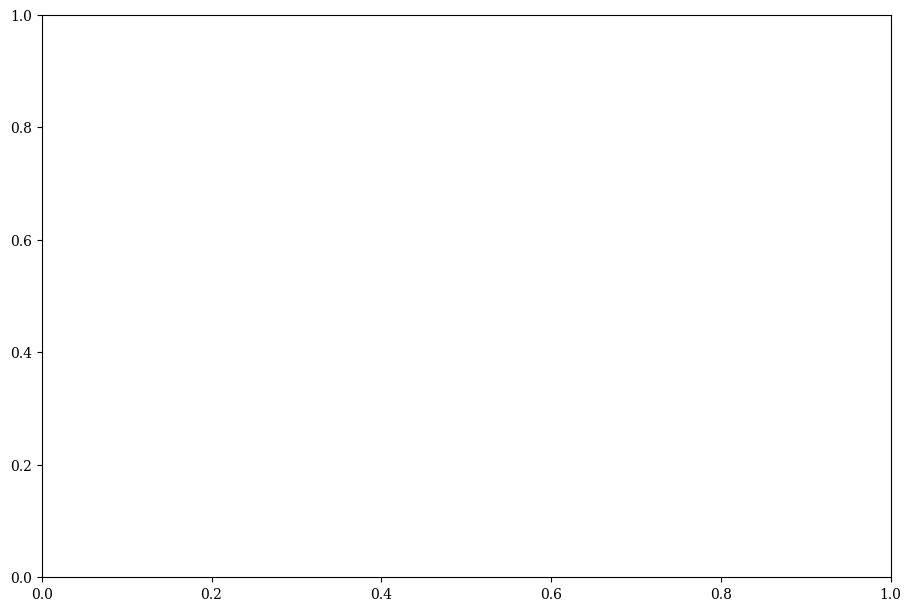

In [14]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf['x']),
    np.unique(newdf['y']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf['x'], newdf['y']),  # Original data points
    newdf['vs'],        # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('E', 'e')] 
mesh=ax.pcolormesh(grid_x, grid_y, grid_z,vmin=0, vmax=1, shading='auto', cmap='viridis')

#plt.xlabel('X')
#plt.ylabel('Y')
#plt.title('Velocity Vector Strength')
#cbar = plt.colorbar(mesh, location='top')

#ax.axis('off')
ax.set_xticks([])
ax.set_yticks([])
ax.quiver(nearest_points['x'], nearest_points['y'], nearest_points['xvel'], nearest_points['yvel'], angles='xy', scale_units='xy',scale=10, color='grey')

#fig.set_edgecolor('darkturquoise')  
#fig.set_linewidth(10)  


for spine in ax.spines.values():
    spine.set_edgecolor('#e95e0dff')#('#57c0e1ff') #((87,192,225,100) )
    spine.set_linewidth(1)  

ax.set_rasterized(True)
ax.set_aspect('equal')
fifi.mpl_functions.set_fontsize(ax, 6)
layout.append_figure_to_layer(layout.figures['E'], 'E', cleartarget=True)

# vorticity

In [15]:
newdf1 = df_XY_steady.groupby(['x','y'], as_index=False,group_keys=False).apply(lambda d: np.sqrt(d['vorticity_x']**2 + d['vorticity_y']**2 +d['vorticity_z']**2).mean())


In [16]:
newdf1.columns = ['x','y','vort']

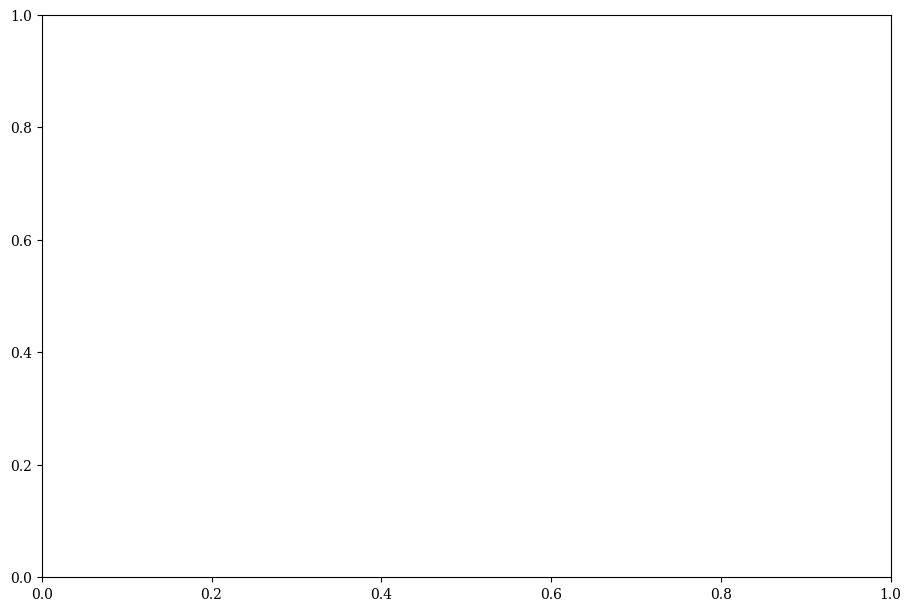

In [17]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['y']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['y']),  # Original data points
    newdf1['vort'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('F', 'f')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=0, vmax=50, shading='auto', cmap=Spectral_half_cmap)

ax.set_xticks([])
ax.set_yticks([])
ax.quiver(nearest_points['x'], nearest_points['y'], nearest_points['xvel'], nearest_points['yvel'], angles='xy', scale_units='xy', scale=10, color='grey')

fifi.mpl_functions.set_fontsize(ax, 6)

for spine in ax.spines.values():
    spine.set_edgecolor('#e95e0dff')#('#57c0e1ff') #((87,192,225,100) )
    spine.set_linewidth(1)  
    
ax.set_aspect('equal')
ax.set_rasterized(True)
layout.append_figure_to_layer(layout.figures['F'], 'F', cleartarget=True)


## Instantaneous vorticity

In [18]:
newdf1 = df_XY_steady[df_XY_steady['Time']==25]

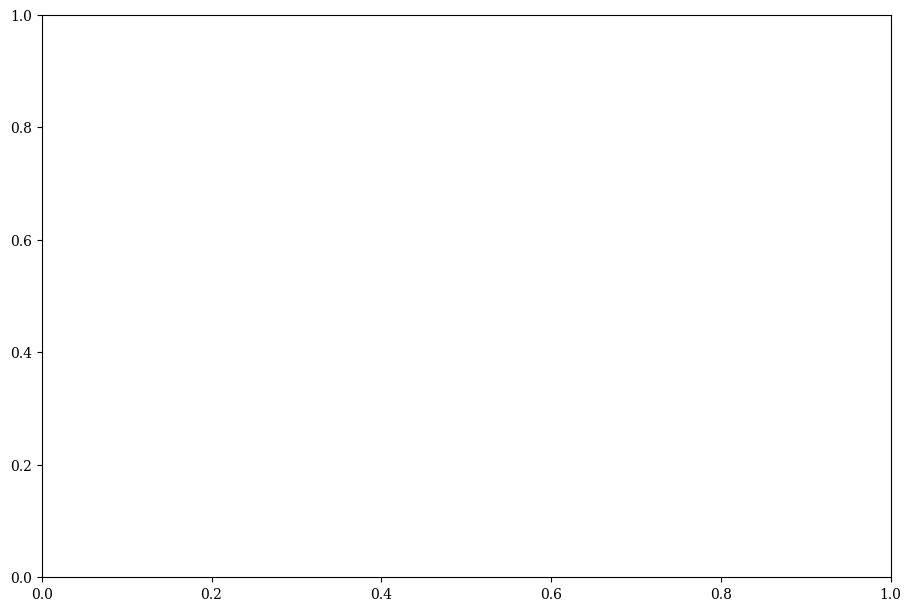

In [19]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['y']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['y']),  # Original data points
    newdf1['vorticity_z'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('G', 'g')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=-50, vmax=50, shading='auto', cmap=cmap_base)

ax.set_xticks([])
ax.set_yticks([])
ax.quiver(nearest_points['x'], nearest_points['y'], nearest_points['xvel'], nearest_points['yvel'], angles='xy', scale_units='xy', scale=10, color='grey')

fifi.mpl_functions.set_fontsize(ax, 6)


for spine in ax.spines.values():
    spine.set_edgecolor('#e95e0dff')# color_blue ('#57c0e1ff') #((87,192,225,100) )
    spine.set_linewidth(1)  
ax.set_aspect('equal')
ax.set_rasterized(True)
layout.append_figure_to_layer(layout.figures['G'], 'G', cleartarget=True)


# XY Unsteady 

## Vector Strength

In [20]:
newdf = df_XY_unsteady.groupby(['x','y'], as_index=False,group_keys=False).apply(lambda d: 1/len(d)*np.sqrt((np.sum(d['unit_xvel'])**2) + (np.sum(d['unit_yvel'])**2)+(np.sum(d['unit_zvel'])**2)))



In [21]:
newdf.columns = ['x','y','vs']

### adding vector fields

In [22]:
XY_unsteady_average = df_XY_unsteady.groupby(['x','y'],as_index=False).mean()

In [23]:

# Create a grid of linearly spaced points within the range of x and y
x_linspace = np.linspace(XY_unsteady_average['x'].min()+.02, XY_unsteady_average['x'].max()-.02, 10)  # 5 points in x
y_linspace = np.linspace(XY_unsteady_average['y'].min()+.02, XY_unsteady_average['y'].max()-.02, 10)  # 5 points in y
X, Y = np.meshgrid(x_linspace, y_linspace)

# Flatten the grid and create a DataFrame
grid_points = pd.DataFrame({
    'x': X.flatten(),
    'y': Y.flatten()
})


# Create a KDTree from the original DataFrame points
tree = KDTree(XY_unsteady_average[['x', 'y']].values)

# Query the nearest points from the tree
distances, indices = tree.query(grid_points)

# Get the corresponding u and v values from the original DataFrame
nearest_points = XY_unsteady_average.iloc[indices]


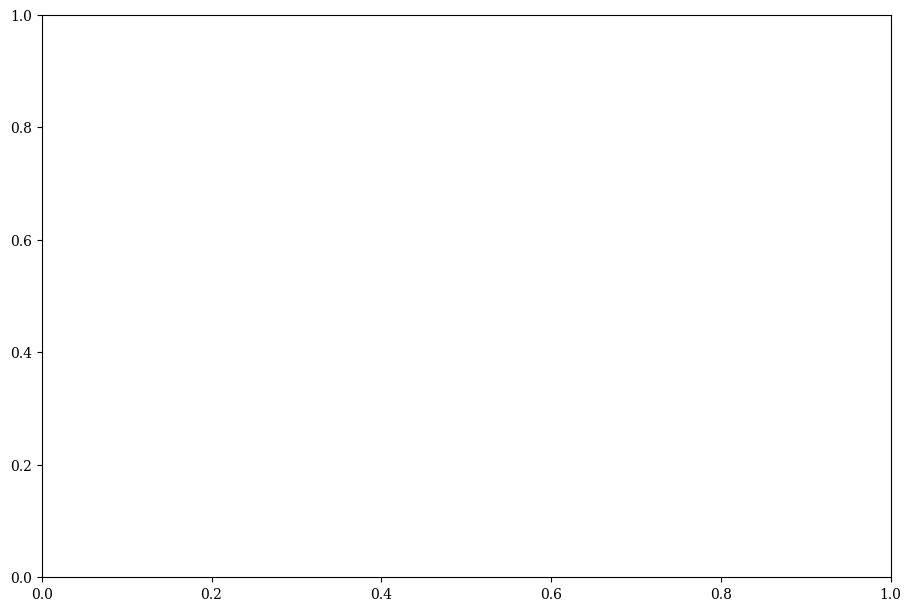

In [24]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf['x']),
    np.unique(newdf['y']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf['x'], newdf['y']),  # Original data points
    newdf['vs'],        # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('H', 'h')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=0, vmax=1, shading='auto', cmap='viridis')

#plt.xlabel('X')
#plt.ylabel('Y')
#plt.title('Velocity Vector Strength')
#cbar = plt.colorbar(mesh, location='top')



ax.quiver(nearest_points['x'], nearest_points['y'], nearest_points['xvel'], nearest_points['yvel'], angles='xy', scale_units='xy', scale=10, color='grey')

#ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#3787c0ff')#('#e1a36dff') #((87,192,225,100) )
    spine.set_linewidth(1)  


fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_aspect('equal')
ax.set_rasterized(True)
layout.append_figure_to_layer(layout.figures['H'], 'H', cleartarget=True)


# vorticity

In [25]:
newdf1 = df_XY_unsteady.groupby(['x','y'], as_index=False,group_keys=False).apply(lambda d: np.sqrt(d['vorticity_x']**2 + d['vorticity_y']**2 ++ d['vorticity_z']**2).mean())


In [26]:
newdf1.columns = ['x','y','vort']

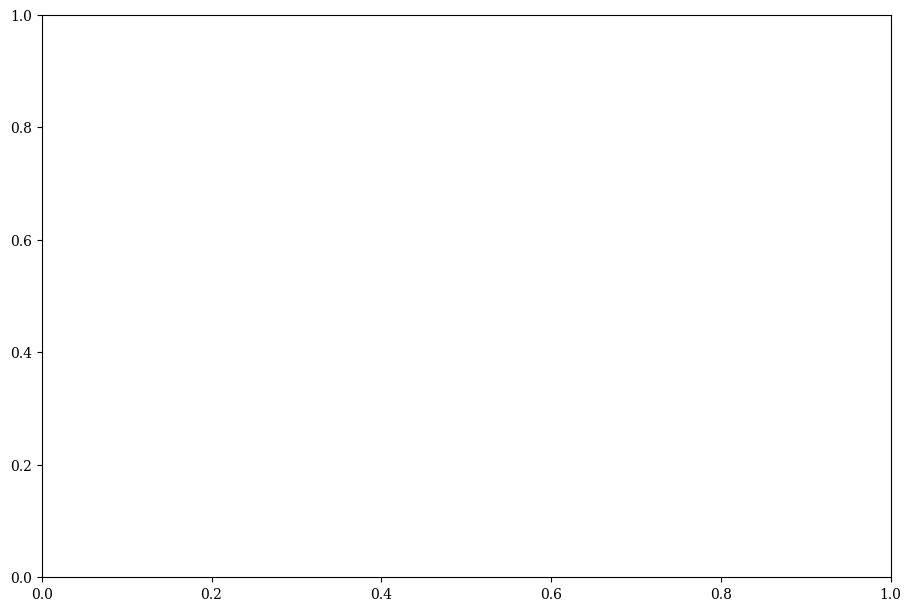

In [27]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['y']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['y']),  # Original data points
    newdf1['vort'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('I', 'i')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=0, vmax=50, shading='auto', cmap=Spectral_half_cmap)


ax.quiver(nearest_points['x'], nearest_points['y'], nearest_points['xvel'], nearest_points['yvel'], angles='xy', scale_units='xy', scale=10, color='grey')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#3787c0ff')#('#e1a36dff') #((87,192,225,100) )
    spine.set_linewidth(1)  


#plt.xlabel('X')
#plt.ylabel('Y')
#plt.title('Mean Vorticity Magnitude')
#cbar = plt.colorbar(mesh, location='top', aspect=50)
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.axis('off')
ax.set_aspect('equal')
ax.set_rasterized(True)
layout.append_figure_to_layer(layout.figures['I'], 'I', cleartarget=True)

## Instantaneous vorticity

In [28]:
newdf1 = df_XY_unsteady[df_XY_unsteady['Time']==25]

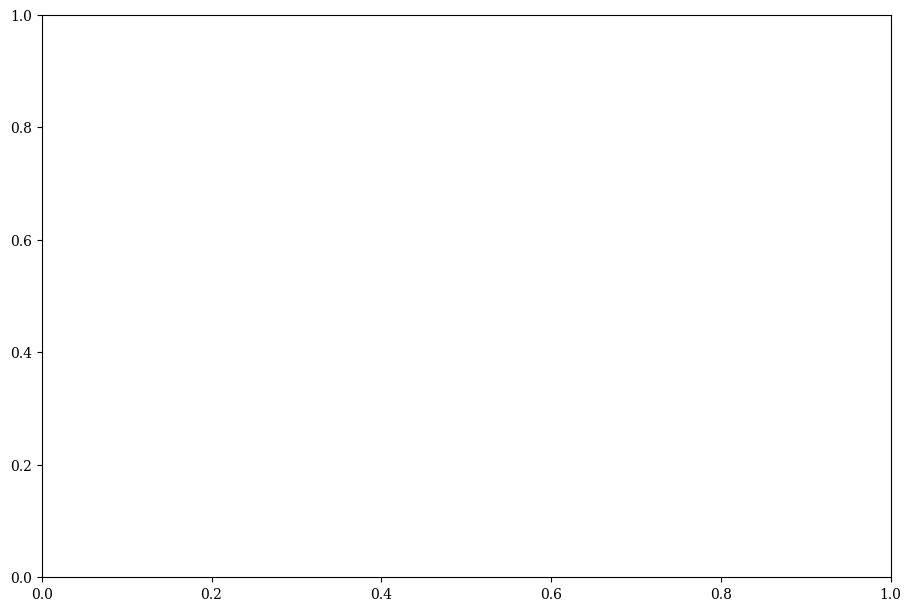

In [29]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['y']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['y']),  # Original data points
    newdf1['vorticity_z'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('J', 'j')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=-50,vmax=50, shading='auto', cmap=cmap_base)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#3787c0ff')# color_orange ('#e1a36dff') #((87,192,225,100) )
    spine.set_linewidth(1)  


ax.quiver(nearest_points['x'], nearest_points['y'], nearest_points['xvel'], nearest_points['yvel'], angles='xy', scale_units='xy', scale=10, color='grey')
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.xlabel('X')
#plt.ylabel('Y')
#plt.title('Instantaneous Y Vorticity')
#cbar = plt.colorbar(mesh, location='top')
ax.set_aspect('equal')
#ax.axis('off')
ax.set_rasterized(True)
layout.append_figure_to_layer(layout.figures['J'], 'J', cleartarget=True)

# XZ plane

## Vector Strength

In [30]:
newdf = df_XZ.groupby(['x','z'], as_index=False,group_keys=False).apply(lambda d: 1/len(d)*np.sqrt((np.sum(d['unit_xvel'])**2) + (np.sum(d['unit_yvel'])**2)+(np.sum(d['unit_zvel'])**2)))



In [31]:
newdf.columns = ['x','z','vs']

### adding vector fields

In [32]:
XZ_average = df_XZ.groupby(['x','z'],as_index=False).mean()

In [33]:

# Create a grid of linearly spaced points within the range of x and y
x_linspace = np.linspace(XZ_average['x'].min()+.02, XZ_average['x'].max()-.02, 10)  # 5 points in x
y_linspace = np.linspace(XZ_average['z'].min()+.02, XZ_average['z'].max()-.02, 10)  # 5 points in y
X, Y = np.meshgrid(x_linspace, y_linspace)

# Flatten the grid and create a DataFrame
grid_points = pd.DataFrame({
    'x': X.flatten(),
    'z': Y.flatten()
})


# Create a KDTree from the original DataFrame points
tree = KDTree(XZ_average[['x', 'z']].values)

# Query the nearest points from the tree
distances, indices = tree.query(grid_points)

# Get the corresponding u and v values from the original DataFrame
nearest_points = XZ_average.iloc[indices]


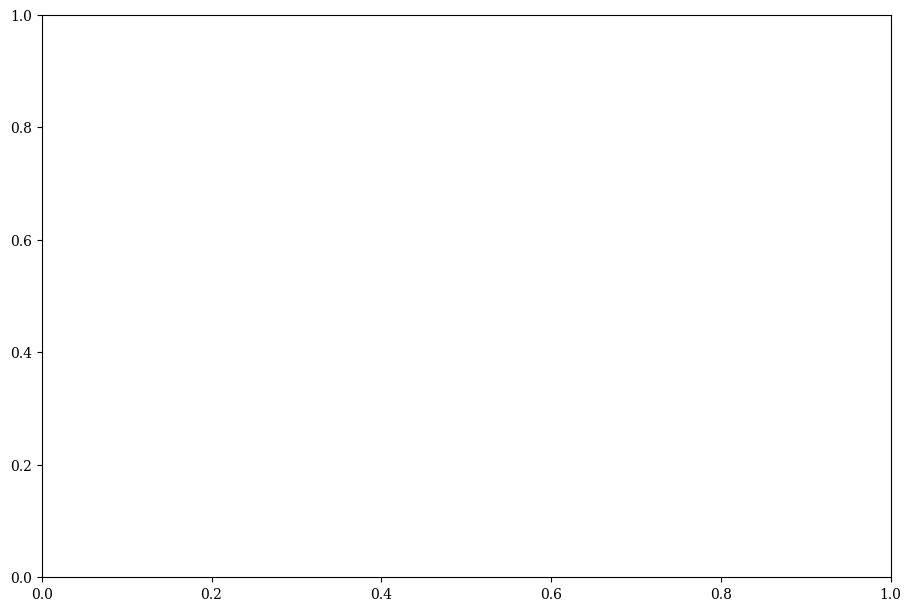

In [34]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf['x']),
    np.unique(newdf['z']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf['x'], newdf['z']),  # Original data points
    newdf['vs'],        # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('K', 'k')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=0, vmax=1, shading='auto', cmap='viridis')

#ax.set_xlabel('X')
#ax.set_ylabel('Z')
#ax.set_title('Velocity Vector Strength')
#fig.colorbar(mesh, location='top',aspect=40).outline.set_visible(False)

ax.quiver(nearest_points['x'], nearest_points['z'], nearest_points['xvel'], nearest_points['zvel'], angles='xy', scale_units='xy', scale=10, color='grey', alpha=.7)
#fifi.mpl_functions.adjust_spines(ax, ['left','bottom'], yticks =[0,0.5], xticks=[0,1.25],  tick_length=3, linewidth=.5)
#ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#dc2b94ff') #((87,192,225,100) )
    spine.set_linewidth(1)  


ax.set_aspect('equal')
fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_rasterized(True)
layout.append_figure_to_layer(layout.figures['K'], 'K', cleartarget=True)

# vorticity

In [35]:
newdf1 = df_XZ.groupby(['x','z'], as_index=False,group_keys=False).apply(lambda d: np.sqrt(d['vorticity_x']**2 + d['vorticity_y']**2 + + d['vorticity_z']**2).mean())
newdf1.columns = ['x','z','vort']

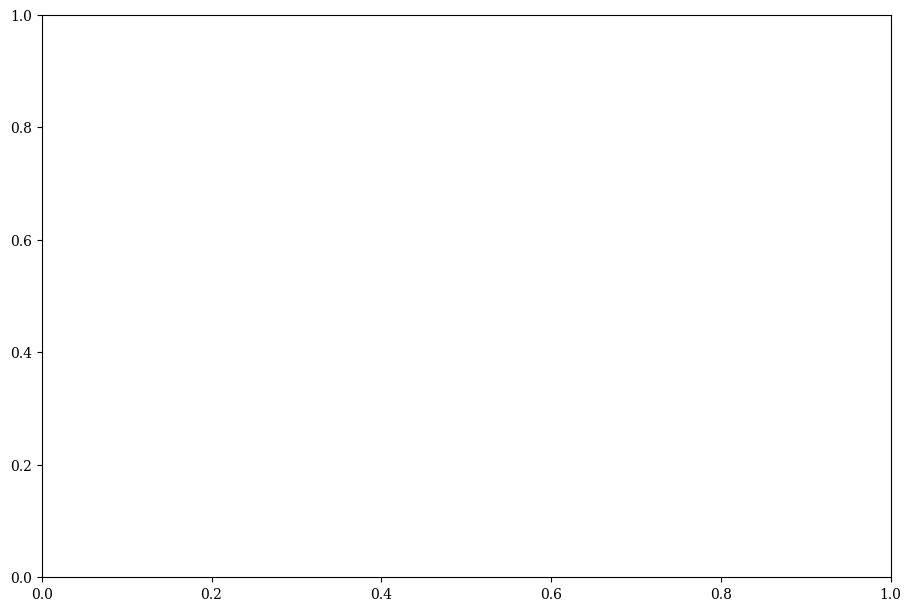

In [36]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['z']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['z']),  # Original data points
    newdf1['vort'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

# Plotting
fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('L', 'l')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=0,vmax=50, shading='auto', cmap=Spectral_half_cmap)

#ax.set_xlabel('X')
#ax.set_ylabel('Z')
#ax.set_title('Velocity Vector Strength')
#fig.colorbar(mesh, location='top',aspect=40).outline.set_visible(False)

ax.quiver(nearest_points['x'], nearest_points['z'], nearest_points['xvel'], nearest_points['zvel'], angles='xy', scale_units='xy', scale=10, color='grey')

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#dc2b94ff') #((87,192,225,100) )
    spine.set_linewidth(1)  


ax.set_aspect('equal')

ax.set_rasterized(True)

fifi.mpl_functions.set_fontsize(ax, 6)

layout.append_figure_to_layer(layout.figures['L'], 'L', cleartarget=True)

## Instantaneous vorticity

In [37]:
newdf1 = df_XZ[df_XZ['Time']==25]

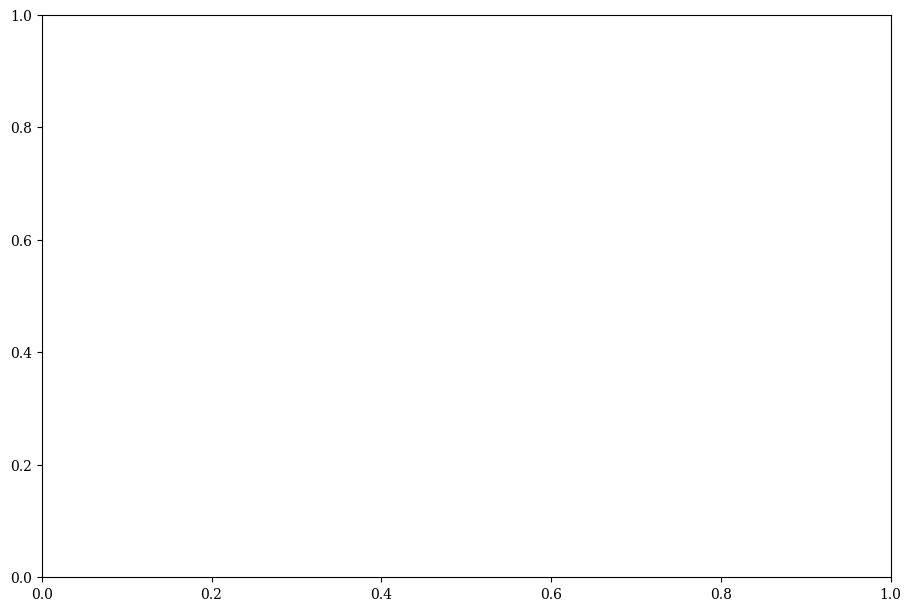

In [38]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['z']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['z']),  # Original data points
    newdf1['vorticity_z'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('M', 'm')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=-50,vmax=50, shading='auto', cmap=cmap_base)

#fig.colorbar(mesh, location='top',aspect=40).outline.set_visible(False)

ax.quiver(nearest_points['x'], nearest_points['z'], nearest_points['xvel'], nearest_points['zvel'], angles='xy', scale_units='xy', scale=10, color='grey')

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#dc2b94ff') #((87,192,225,100) ) #f747a5ff
    spine.set_linewidth(1)  


ax.set_aspect('equal')

ax.set_rasterized(True)

fifi.mpl_functions.set_fontsize(ax, 6)

layout.append_figure_to_layer(layout.figures['M'], 'M', cleartarget=True)

## FFTs


### Austin's anemometer measurement locations: 

### For the horizontal spitter plate

steady:[0.5334, 0.2413, 0.1143], 
unsteady:[0.5334, 0.2413, 0.381],  
laminar: [0.5334, 0.2413, 0.2413]

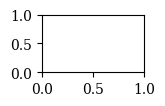

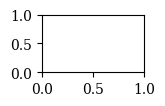

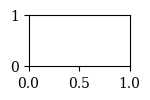

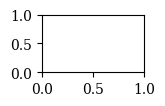

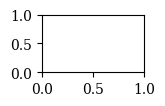

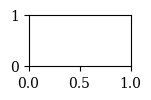

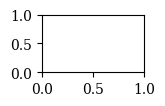

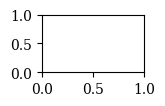

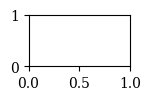

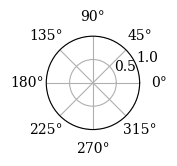

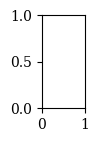

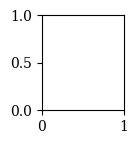

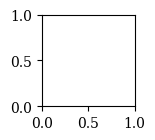

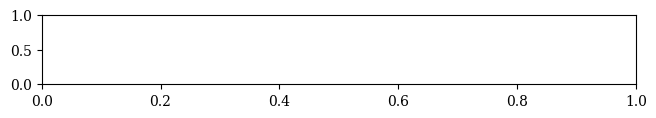

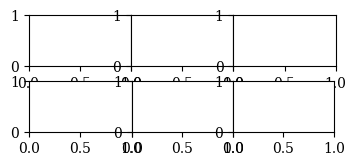

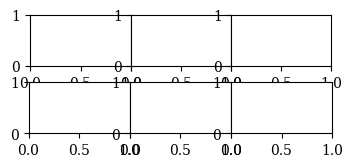

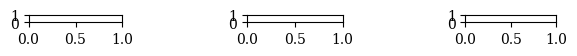

In [83]:
layout = fifi.svg_to_axes.FigureLayout('f2_draft_v7.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])


In [39]:
df_loc_steady = df_XY_steady[(df_XY_steady.x==np.float32(0.81556)) & (df_XY_steady.y==np.float32(.21601))].copy()

In [40]:
df_loc_unsteady = df_XY_unsteady [(df_XY_unsteady.x==np.float32(0.81556)) & (df_XY_unsteady.y==np.float32(.21601))].copy()

In [41]:
df_loc_steady['3d_speed']= np.sqrt(df_loc_steady.xvel**2 + df_loc_steady.yvel**2 + df_loc_steady.zvel**2)
df_loc_unsteady['3d_speed']= np.sqrt(df_loc_unsteady.xvel**2 + df_loc_unsteady.yvel**2 + df_loc_unsteady.zvel**2)

In [42]:
df_loc_steady['2d_speed']= np.sqrt(df_loc_steady.xvel**2 + df_loc_steady.yvel**2 )
df_loc_unsteady['2d_speed']= np.sqrt(df_loc_unsteady.xvel**2 + df_loc_unsteady.yvel**2 )

In [43]:

freqs_s, ps_s, psd_s =WindDataProcessing.FFT(df_loc_steady['2d_speed'], dt=.1)

freqs_uns, ps_uns, psd_uns = WindDataProcessing.FFT(df_loc_unsteady['2d_speed'], dt=.1)

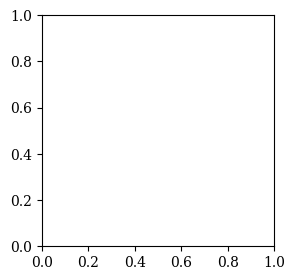

In [79]:
fig, ax = plt.subplots(figsize=(3,3))
ax = layout.axes[('A', 'a')]

ax.loglog(freqs_s, psd_s, linewidth=1, label='xy speed',color=color_blue,alpha=.95)

ax.loglog(freqs_uns, psd_uns, linewidth=1, label='xy speed',color=color_orange,alpha=.95)
ax.set_xlim([10**-2, 10**1])
ax.set_ylim([10**-8, 10**-1])
fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'], yticks =[10**-8, 10**-1], xticks=[10**-2, 10**1],
                                tick_length=3,spine_locations={'left': 5, 'bottom': 5}, linewidth=1)

ax.set_ylabel('Power Spectral \n Density \n'+ r'$\left(\frac{(\mathrm{m/s})^2}{\mathrm{Hz}}\right)$' ,labelpad=-10)
ax.set_xlabel('Frequency (Hz)',labelpad=-1)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.minorticks_off()

fifi.mpl_functions.set_fontsize(ax, 6)
layout.append_figure_to_layer(layout.figures['A'], 'A', cleartarget=True)


fig, ax = plt.subplots(figsize=(10,3))


plt.loglog(freqs_x, psd_x, label='x', )

plt.loglog(freqs_y, psd_y, label='y', )
plt.loglog(freqs_z, psd_z, label='z', )



plt.legend()
plt.xlabel('Frequency')
plt.ylabel('PSD')
plt.xlim(.01,10**1)


# Time Series Plots

In [45]:
df_XY_steady['D'] = np.arctan2(df_XY_steady['yvel'], df_XY_steady['xvel'])
df_XY_steady['s2'] = np.sqrt(df_XY_steady['yvel']**2 + df_XY_steady['xvel']**2)

df_XY_unsteady['D'] = np.arctan2(df_XY_unsteady['yvel'], df_XY_unsteady['xvel'])
df_XY_unsteady['s2'] =  np.sqrt(df_XY_unsteady['yvel']**2 + df_XY_unsteady['xvel']**2)

In [46]:
middle_point_steady = df_XY_steady[(df_XY_steady['x']==np.float32(0.81556) )& (df_XY_steady['y']==np.float32(.21601))].copy()
middle_point_unsteady = df_XY_unsteady[(df_XY_unsteady['x']==np.float32(0.81556) )& (df_XY_unsteady['y']==np.float32(.21601))].copy()

In [47]:
#middle_point_steady = df_XY_steady[(df_XY_steady['x']==np.float32(0.70159) )& (df_XY_steady['y']==np.float32(.2413))].copy()

#middle_point_unsteady = df_XY_unsteady[(df_XY_unsteady['x']==np.float32(0.70159) )& (df_XY_unsteady['y']==np.float32(.2413))].copy()

In [48]:
middle_point_steady.Time = middle_point_steady.Time-10

middle_point_unsteady.Time = middle_point_unsteady.Time-10

In [49]:
#middle_point_steady[['x','y','z','xvel','yvel','zvel','vorticity_x', 'vorticity_y','vorticity_z','Time']].to_hdf('../../../Data/Fig1_Input_Data/steady_timeseries.hdf', key='time')
#middle_point_unsteady[['x','y','z','xvel','yvel','zvel','vorticity_x', 'vorticity_y','vorticity_z','Time']].to_hdf('../../../Data/Fig1_Input_Data/unsteady_timeseries.hdf', key='time')




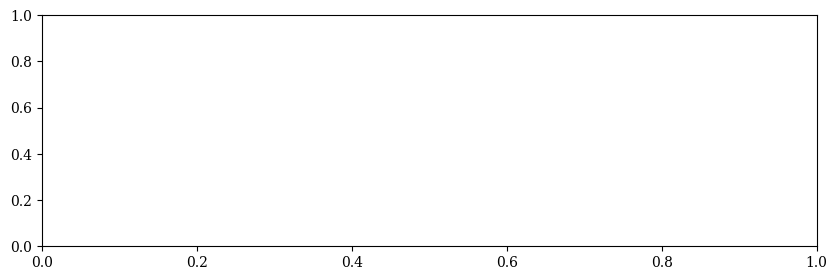

In [84]:
fig, ax=plt.subplots(figsize=(10,3))
ax = layout.axes[('N', 'n')]
ax.plot(middle_point_steady.Time, middle_point_steady['s2'], color=color_blue, label='steady')

ax.plot(middle_point_unsteady.Time, middle_point_unsteady['s2'], color=color_orange, label='unsteady')
#plt.gca().set_aspect('equal')
ax.set_ylim(0,1.5)
#plt.xlabel('Time (s)')
#plt.ylabel('wind speed')
#plt.legend()


fifi.mpl_functions.adjust_spines(ax, ['left','bottom'], yticks =[0,0.5,1,1.5], xticks=[5,10,15,20,25],  tick_length=3,spine_locations={'left': 5, 'bottom': 5},
                                         linewidth=1)

ax.set_aspect('equal')



ax.set_ylabel('Wind Speed \n (m/s)')
ax.set_xlabel('Time (s)')


fifi.mpl_functions.set_fontsize(ax, 6)

layout.append_figure_to_layer(layout.figures['N'], 'N', cleartarget=True)

In [51]:
#inlet_x= .27
#outlet_x= 1.18

In [52]:
# take some extra points around the area for added measurements
middle_points_steady = df_XY_steady[(df_XY_steady['x'].between(0.81,.83) )& (df_XY_steady['y'].between(.2,.24))].copy()

middle_points_unsteady = df_XY_unsteady[(df_XY_unsteady['x'].between(0.81,.83)  )& (df_XY_unsteady['y'].between(.2,.24))].copy()

In [90]:
middle_points_steady.x.max()-middle_points_steady.x.min()

0.018130004405975342

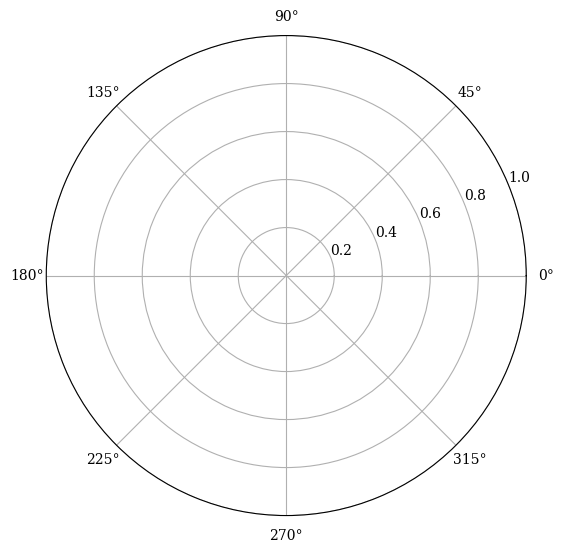

In [85]:
# Create a new figure
fig = plt.figure()

# Add an axes to the figure, specifying it as a polar plot
ax = fig.add_axes([0, 0, 1, 1], polar=True)
ax = layout.axes[('B', 'b')]
ax.scatter(middle_points_steady['D'],middle_points_steady['s2'],s=.2, edgecolor=None, color=color_blue, alpha=1)
ax.scatter(middle_points_unsteady['D'],middle_points_unsteady['s2'],s=.2,  edgecolor=None, color=color_orange, alpha=1)

ax.set_rmax(1.5)
ax.set_rticks([0.75,1])  # Less radial ticks

# ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/2, np.pi , -3*np.pi/2, -np.pi/2, -np.pi/4])
#ax.set_xticklabels(['0', '$-\pi/4$', '$-\pi/2$', '$-3\pi/4$', '$\pm\pi$', '$3\pi/4$', '$\pi/2$', '$\pi/4$'])
ax.set_xticklabels([])

# Set the yticks off
ax.set_yticks([.75,1.5])
ax.set_yticklabels([0.75, 1.5])

# Set the direction of the plot to clockwise
ax.set_rlabel_position(180)
ax.set_theta_direction(-1)

# Set the zero to the top
ax.set_theta_offset(0)

fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['B'], 'B', cleartarget=True)


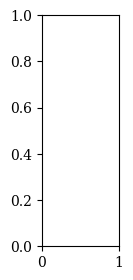

In [55]:

fig,ax = plt.subplots(figsize=(1,3))
ax = layout.axes[('C', 'c')]

feature_val = middle_points_steady.zvel.values # df.groupby('obj_id_unique')[feature_name].mean().values 

b, h = np.histogram(feature_val)
fpl.scatter_box_violin_distribution(ax, 0, feature_val, b, h,markersize=1, shading=1, edgecolor=None, linewidth=None, color=color_blue)


feature_val = middle_points_unsteady.zvel.values # df.groupby('obj_id_unique')[feature_name].mean().values 

b, h = np.histogram(feature_val)
#,markersize=0.2, edgecolor=None, 

fpl.scatter_box_violin_distribution(ax, 1, feature_val, b, h,markersize=1, shading=1, edgecolor=None, linewidth=None,color=color_orange)

#ax, x, y_data, hist_counts, hist_bins,


fifi.mpl_functions.adjust_spines(ax, ['left'], yticks =[-1,-.5,0,.5,1], spine_locations={'left': 2}, tick_length=3, linewidth=1)
ax.set_yticklabels([-1,-.5,0,.5,1])

ax.set_ylabel('Vertical Wind Velocity \n (m/s)')



fifi.mpl_functions.set_fontsize(ax, 6)
layout.append_figure_to_layer(layout.figures['C'], 'C', cleartarget=True)


In [56]:
# take some extra points around the area for added measurements
middle_points_steady = df_XY_steady[(df_XY_steady['x'].between(0.81,.83) )& (df_XY_steady['y'].between(.2,.24))].copy()

middle_points_unsteady = df_XY_unsteady[(df_XY_unsteady['x'].between(0.81,.83)  )& (df_XY_unsteady['y'].between(.2,.24))].copy()

In [57]:
m1 =middle_points_steady[middle_points_steady.Time.between(15,19.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
m2 =middle_points_steady[middle_points_steady.Time.between(20,24.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
m3 = middle_points_steady[middle_points_steady.Time.between(25,29.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
m4 = middle_points_steady[middle_points_steady.Time.between(30,34.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))

circstd_df_steady = pd.concat([m1,m2,m3,m4])
circstd_df_steady.columns=['x','y','dir_std']

n1 =middle_points_steady[middle_points_steady.Time.between(15,19.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
n2 =middle_points_steady[middle_points_steady.Time.between(20,24.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
n3 = middle_points_steady[middle_points_steady.Time.between(25,29.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
n4 = middle_points_steady[middle_points_steady.Time.between(30,34.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
ti_df_steady = pd.concat([n1,n2,n3,n4])
ti_df_steady.columns=['x','y','ti']
ti_df_steady['dir_std']= circstd_df_steady['dir_std']
ti_v_dir_steadydf =ti_df_steady



In [74]:
m1 =middle_points_unsteady[middle_points_unsteady.Time.between(15,19.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
m2 =middle_points_unsteady[middle_points_unsteady.Time.between(20,24.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
m3 = middle_points_unsteady[middle_points_unsteady.Time.between(25,29.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
m4 = middle_points_unsteady[middle_points_unsteady.Time.between(30,34.9)].groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))

circstd_df_unsteady = pd.concat([m1,m2,m3,m4])
circstd_df_unsteady.columns=['x','y','dir_std']

n1 =middle_points_unsteady[middle_points_unsteady.Time.between(15,19.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
n2 =middle_points_unsteady[middle_points_unsteady.Time.between(20,24.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
n3 = middle_points_unsteady[middle_points_unsteady.Time.between(25,29.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
n4 = middle_points_unsteady[middle_points_unsteady.Time.between(30,34.9)].groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
ti_df_unsteady = pd.concat([n1,n2,n3,n4])
ti_df_unsteady.columns=['x','y','ti']

ti_df_unsteady['dir_std']= circstd_df_unsteady['dir_std']

ti_v_dir_unsteadydf = ti_df_unsteady


In [365]:
circstd_df_unsteady = pd.concat([m1,m2,m3,m4])
circstd_df_unsteady.columns=['x','y','dir_std']
ti_df_unsteady = pd.concat([n1,n2,n3,n4])
ti_df_unsteady.columns=['x','y','ti']
ti_df_unsteady['dir_std']= circstd_df_unsteady['dir_std']

ti_v_dir_unsteadydf = ti_df_unsteady

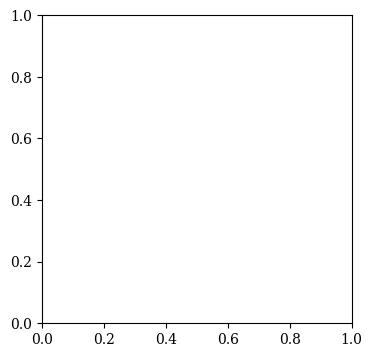

In [80]:
fig,ax = plt.subplots(figsize=(4,4))

ax = layout.axes[('D', 'd')]

ax.scatter(ti_v_dir_steadydf.dir_std, ti_v_dir_steadydf.ti, s=20,  alpha=0.5, color=color_blue)
ax.scatter(ti_v_dir_unsteadydf.dir_std, ti_v_dir_unsteadydf.ti,  s=20, alpha=0.5, color=color_orange)




############
ax.set_xlim(0,95)
ax.set_ylim(0,.85)
fifi.mpl_functions.adjust_spines(ax, ['left','bottom'], yticks =[0,.2,.4,.6,.8], xticks=[0,30,60,90],
                                  spine_locations={'left': 5, 'bottom': 5}, tick_length=3, linewidth=1)


ax.set_ylabel('Turbulence Intensity')
ax.set_xlabel('Standard deviation in \n direction ($^\circ$)')


fifi.mpl_functions.set_fontsize(ax, 6)

layout.append_figure_to_layer(layout.figures['D'], 'D', cleartarget=True)


fig,ax = plt.subplots(figsize=(4,4))

#ax = layout.axes[('D', 'd')]

ax.scatter(ti_v_dir_steadydf.dir_std, ti_v_dir_steadydf.ti, s=20,  color=color_blue)
ax.scatter(ti_v_dir_unsteadydf.dir_std, ti_v_dir_unsteadydf.ti,  s=20,  color=color_orange)



ax.set_xlim(0,90)
ax.set_ylim(0,.8)


fifi.mpl_functions.adjust_spines(ax, ['left','bottom'], yticks =[0,.2,.4,.6,0.8], xticks=[0,30,60,90], spine_locations={'left': 5, 'bottom': 5}, tick_length=3, linewidth=1)

ax.set_ylabel('Turbulence Intensity')
ax.set_xlabel('Standard Deviation in \n Direction ($^\circ$)')


fifi.mpl_functions.set_fontsize(ax, 6)

#layout.append_figure_to_layer(layout.figures['D'], 'D', cleartarget=True)


# Plume snapshots

In [61]:
circstd_df_steady = middle_points_steady.groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
circstd_df_steady.columns=['x','y','dir_std']
ti_df_steady = middle_points_steady.groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
ti_df_steady.columns=['x','y','ti']

ti_v_dir_steadydf = pd.merge(circstd_df_steady, ti_df_steady)


circstd_df_unsteady = middle_points_unsteady.groupby(['x','y'], as_index=False).apply(lambda d: WindDataProcessing.circstd(d.D, high=np.pi, low=-np.pi))
circstd_df_unsteady.columns=['x','y','dir_std']
ti_df_unsteady = middle_points_unsteady.groupby(['x','y'], as_index=False).apply(lambda d: np.std(d.s2)/np.mean(d.s2))
ti_df_unsteady.columns=['x','y','ti']

ti_v_dir_unsteadydf = pd.merge(circstd_df_unsteady, ti_df_unsteady)

In [62]:
steady_25 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XY_steady_plume/plume_100.csv')
steady_30 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XY_steady_plume/plume_150.csv')
steady_35 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XY_steady_plume/plume_200.csv')

In [63]:
unsteady_25 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XY_unsteady_plume/plume_100.csv')
unsteady_30 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XY_unsteady_plume/plume_150.csv')
unsteady_35 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XY_unsteady_plume/plume_200.csv')

In [64]:
XZ_25 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XZ_slice_plume/plume_100.csv')
XZ_30 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XZ_slice_plume/plume_150.csv')
XZ_35 = pd.read_csv('../../../Data/CFD/2D_PlumeData/XZ_slice_plume/plume_200.csv')

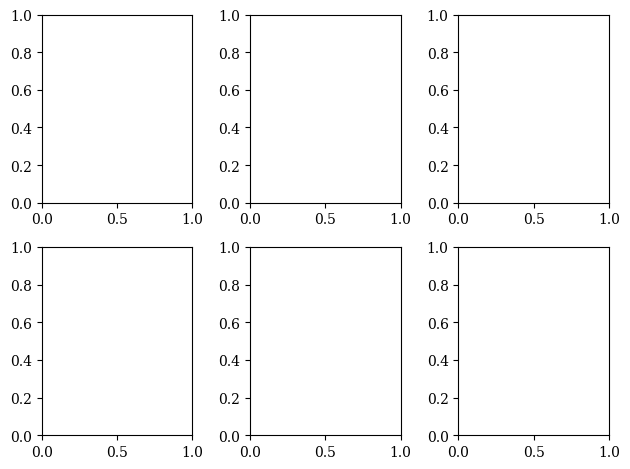

In [69]:
cmap_1 = 'pink'
# Create a vector field plot with the nearest points
fig,ax=plt.subplots(nrows=2, ncols=3, layout='tight',  squeeze=False)
ax[0,0] = layout.axes[('O', 'o1')]
ax[0,1] = layout.axes[('O', 'o2')]
ax[0,2] = layout.axes[('O', 'o3')]
ax[1,0] = layout.axes[('O', 'o4')]
ax[1,1] = layout.axes[('O', 'o5')]
ax[1,2] = layout.axes[('O', 'o6')]

##------------ Top Row (XY, steady) -------------
# Prepare the grid
grid_x, grid_y = np.meshgrid(np.unique(steady_25['Points:0']), np.unique(steady_25['Points:2']),)

# Time 15s
grid_z = griddata((steady_25['Points:0'], steady_25['Points:2']), steady_25['s3'], (grid_x, grid_y),  method='linear' )

mesh=ax[0,0].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=2000,  cmap=cmap_1)
#ax[0,0].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)


# Time 20s
grid_z = griddata((steady_30['Points:0'], steady_30['Points:2']), steady_30['s3'], (grid_x, grid_y),  method='linear' )

mesh=ax[0,1].pcolormesh(grid_x, grid_y, grid_z,vmin=0,vmax=2000, shading='nearest',  cmap=cmap_1)
#ax[0,1].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)



# Time 25s
grid_z = griddata((steady_35['Points:0'], steady_35['Points:2']), steady_35['s3'], (grid_x, grid_y),  method='linear' )

mesh=ax[0,2].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=2000,  cmap=cmap_1)

#cbar = plt.colorbar(mesh, location='top', aspect=50)
#ax[0,2].axis('off')


##------------ Bottom Row (XZ, unsteady) -------------


# Prepare the grid
grid_x, grid_y = np.meshgrid(np.unique(XZ_25['Points:0']), np.unique(XZ_25['Points:1']),)

# Interpolate to fill missing values
grid_z = griddata((XZ_25['Points:0'], XZ_25['Points:1']), XZ_25['s3'], (grid_x, grid_y),  method='linear' )

mesh=ax[1,0].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=2000,  cmap=cmap_1)
#ax[1,0].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)


# Interpolate to fill missing values
grid_z = griddata((XZ_30['Points:0'], XZ_30['Points:1']), XZ_30['s3'], (grid_x, grid_y),  method='linear' )

mesh=ax[1,1].pcolormesh(grid_x, grid_y, grid_z,vmin=0,vmax=2000, shading='nearest',  cmap=cmap_1)
#ax[1,1].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)



# Interpolate to fill missing values
grid_z = griddata((XZ_35['Points:0'], XZ_35['Points:1']), XZ_35['s3'], (grid_x, grid_y),  method='linear' )

mesh=ax[1,2].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=2000,  cmap=cmap_1)

#cbar = plt.colorbar(mesh, location='top', aspect=50)
#ax[1,2].axis('off')


#fig.colorbar(mesh, location='right', aspect=40, ticks= [0,2000]).outline.set_visible(False)

#fifi.mpl_functions.adjust_spines(ax[1,0], ['left','bottom'], yticks =[0,0.25,.50], xticks=[0,1.25],  tick_length=3, linewidth=.5)

fifi.mpl_functions.set_fontsize(ax[0,0], 6)
fifi.mpl_functions.set_fontsize(ax[0,1], 6)
fifi.mpl_functions.set_fontsize(ax[0,2], 6)
fifi.mpl_functions.set_fontsize(ax[1,0], 6)
fifi.mpl_functions.set_fontsize(ax[1,1], 6)
fifi.mpl_functions.set_fontsize(ax[1,2], 6)


ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[0,2].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')
ax[1,2].set_aspect('equal')


ax[0,0].set_rasterized(True)
ax[0,1].set_rasterized(True)
ax[0,2].set_rasterized(True)
ax[1,0].set_rasterized(True)
ax[1,1].set_rasterized(True)
ax[1,2].set_rasterized(True)



#ax.set_xticks([])
#ax.set_yticks([])
for i, ax in enumerate([ax[0,0],ax[0,1],ax[0,2], ax[1,0],ax[1,1],ax[1,2]]):
    ax.set_xticks([])
    ax.set_yticks([])
    if i<3:
        for spine in ax.spines.values():
            spine.set_edgecolor('#e95e0dff')# color_blue('#57c0e1ff') # #xy_s: '#57c0e1ff' , xy_uns: '#e1a36dff', xz: '#f747a5ff'
            spine.set_linewidth(1)  
    if i>=3:        
        for spine in ax.spines.values():
            spine.set_edgecolor('#dc2b94ff') #((87,192,225,100) ) f747a5ff
            spine.set_linewidth(1) 


layout.append_figure_to_layer(layout.figures['O'], 'O', cleartarget=True)

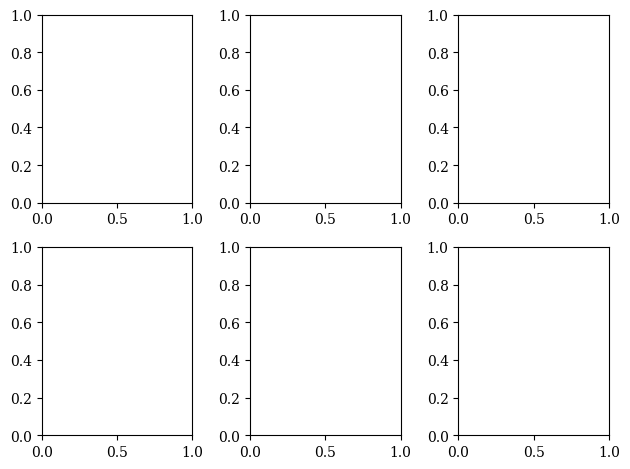

In [70]:

# Create a vector field plot with the nearest points
fig,ax=plt.subplots(nrows=2, ncols=3,layout='tight')

ax[0,0] = layout.axes[('P', 'p1')]
ax[0,1] = layout.axes[('P', 'p2')]
ax[0,2] = layout.axes[('P', 'p3')]
ax[1,0] = layout.axes[('P', 'p4')]
ax[1,1] = layout.axes[('P', 'p5')]
ax[1,2] = layout.axes[('P', 'p6')]

##------------ Top Row (XY, steady) -------------
# Prepare the grid
grid_x, grid_y = np.meshgrid(np.unique(unsteady_25['Points:0']), np.unique(unsteady_25['Points:2']),)

# Time 25s
grid_z = griddata((unsteady_25['Points:0'], unsteady_25['Points:2']), unsteady_25['s1'], (grid_x, grid_y),  method='linear' )

mesh=ax[0,0].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=1000,  cmap=cmap_1)
#ax[0,0].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)


# Time 30s
grid_z = griddata((unsteady_30['Points:0'], unsteady_30['Points:2']), unsteady_30['s1'], (grid_x, grid_y),  method='linear' )

mesh=ax[0,1].pcolormesh(grid_x, grid_y, grid_z,vmin=0,vmax=1000, shading='nearest',  cmap=cmap_1)
#ax[0,1].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)



# Time 35s
grid_z = griddata((unsteady_35['Points:0'], unsteady_35['Points:2']), unsteady_35['s1'], (grid_x, grid_y),  method='linear' )

mesh=ax[0,2].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=1000,  cmap=cmap_1)

#cbar = plt.colorbar(mesh, location='top', aspect=50)
#ax[0,2].axis('off')


##------------ Bottom Row (XZ, unsteady) -------------


# Prepare the grid
grid_x, grid_y = np.meshgrid(np.unique(XZ_25['Points:0']), np.unique(XZ_25['Points:1']),)

# Interpolate to fill missing values
grid_z = griddata((XZ_25['Points:0'], XZ_25['Points:1']), XZ_25['s1'], (grid_x, grid_y),  method='linear' )

mesh=ax[1,0].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=1000,  cmap=cmap_1)
#ax[1,0].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)


# Interpolate to fill missing values
grid_z = griddata((XZ_30['Points:0'], XZ_30['Points:1']), XZ_30['s1'], (grid_x, grid_y),  method='linear' )

mesh=ax[1,1].pcolormesh(grid_x, grid_y, grid_z,vmin=0,vmax=1000, shading='nearest',  cmap=cmap_1)
#ax[1,1].axis('off')
#cbar = plt.colorbar(mesh, location='top', aspect=50)



# Interpolate to fill missing values
grid_z = griddata((XZ_35['Points:0'], XZ_35['Points:1']), XZ_35['s1'], (grid_x, grid_y),  method='linear' )

mesh=ax[1,2].pcolormesh(grid_x, grid_y, grid_z, shading='nearest',vmin=0,vmax=1000,  cmap=cmap_1)

#cbar = plt.colorbar(mesh, location='top', aspect=50)
#ax[1,2].axis('off')


#plt.colorbar(mesh,  ticks= [0,2000])

#cb.outline.set_visible(False)

#fifi.mpl_functions.adjust_spines(ax[0,0], ['left','bottom'], yticks =[0,0.25,.50], xticks=[0,1.25],  tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1,0], ['left','bottom'], yticks =[0,0.25,.50], xticks=[0,1.25],  tick_length=3, linewidth=.5)

fifi.mpl_functions.set_fontsize(ax[0,0], 6)
fifi.mpl_functions.set_fontsize(ax[0,1], 6)
fifi.mpl_functions.set_fontsize(ax[0,2], 6)
fifi.mpl_functions.set_fontsize(ax[1,0], 6)
fifi.mpl_functions.set_fontsize(ax[1,1], 6)
fifi.mpl_functions.set_fontsize(ax[1,2], 6)



ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[0,2].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')
ax[1,2].set_aspect('equal')

ax[0,0].set_rasterized(True)
ax[0,1].set_rasterized(True)
ax[0,2].set_rasterized(True)
ax[1,0].set_rasterized(True)
ax[1,1].set_rasterized(True)
ax[1,2].set_rasterized(True)



for i, ax in enumerate([ax[0,0],ax[0,1],ax[0,2], ax[1,0],ax[1,1],ax[1,2]]):
    ax.set_xticks([])
    ax.set_yticks([])
    if i<3:
        for spine in ax.spines.values():
            spine.set_edgecolor('#3787c0ff')#color_orange ('#e1a36dff') # #xy_s: '#57c0e1ff' , xy_uns: '#e1a36dff', xz: '#f747a5ff'
            spine.set_linewidth(1)  
    if i>=3:        
        for spine in ax.spines.values():
            spine.set_edgecolor('#dc2b94ff') #((87,192,225,100) ) '#f747a5ff'
            spine.set_linewidth(1) 

        

layout.append_figure_to_layer(layout.figures['P'], 'P', cleartarget=True)

In [86]:
layout.write_svg('f2_CFD.svg')